In [ ]:
# Install these libraries
!pip install prophet

In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import math
import itertools
from scipy import stats
import time

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import seaborn as sns

# Date libraries
from dateutil import parser
from datetime import datetime, date
from datetime import timedelta

# Prophet libraries
from prophet import Prophet
from prophet.diagnostics import performance_metrics, cross_validation
from prophet.plot import plot_cross_validation_metric

# Pandas options
pd.set_option("display.float_format", lambda x: "%.2f" % x)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [3]:
# Function to check for missing values
def missing_value_percentage(df):
  """
  Returns the percentage of missing values for each column (rounded to 2 decimals).
  """
  return (df.isnull().mean() * 100).round(2)

# Function to calculate MAPE value
def mean_absolute_percentage_error(actual, pred):
  """
  Returns Mean Absolute Percentage Error (MAPE).
  """
  actual, pred = np.array(actual), np.array(pred)
  return np.mean(np.abs((actual - pred) / actual)) * 100

# Function to calculate WMAPE value
def weighted_mape(actual, pred):
    """Returns Weighted Mean Absolute Percentage Error (WMAPE)."""

    return (abs(actual - pred).sum() / actual.sum()) * 100

Load the Data

In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rajan1999","key":"f81a67dde166587f5cc8ce53caa18315"}'}

In [ ]:
# Configure Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download dataset
!kaggle competitions download -c store-sales-time-series-forecasting

100% 21.4M/21.4M [00:00<00:00, 129MB/s] 



In [ ]:
# Extract files
!unzip store-sales-time-series-forecasting.zip

Archive:  store-sales-time-series-forecasting.zip
  inflating: holidays_events.csv     
  inflating: oil.csv                 
  inflating: sample_submission.csv   
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               
  inflating: transactions.csv        


In [8]:
train = pd.read_csv("train.csv", parse_dates = ["date"])
oil = pd.read_csv("oil.csv", parse_dates = ["date"])
transactions = pd.read_csv("transactions.csv", parse_dates = ["date"])
holidays = pd.read_csv("holidays_events.csv", parse_dates = ["date"])

In [9]:
# Create dicts of your dataframes
dfs = {"train": train, "oil": oil, "transactions": transactions, "holidays": holidays}

# Iterate through the dict
for name, df in dfs.items():
  print(f"Top five rows for {name}:")
  print("\n")
  display(df.head())
  print("\n" + "-"*100 + "\n")

Top five rows for train:




,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0



----------------------------------------------------------------------------------------------------

Top five rows for oil:




,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20



----------------------------------------------------------------------------------------------------

Top five rows for transactions:




,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



----------------------------------------------------------------------------------------------------

Top five rows for holidays:




,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



----------------------------------------------------------------------------------------------------



In [10]:
# Create dicts of your dataframes
dfs = {"train": train, "oil": oil, "transactions": transactions, "holidays": holidays}

# Iterate through the dict
for name, df in dfs.items():
  print(f"Info for the DataFrame: {name}:")
  print("\n")
  df.info()
  print("\n" + "-"*60 + "\n")

Info for the DataFrame: train:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB

------------------------------------------------------------

Info for the DataFrame: oil:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB

-------------------------------------------------------

In [11]:
# Check date range
min(train["date"]), max(train["date"])

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

## **Exploratory Data Analysis (EDA)**

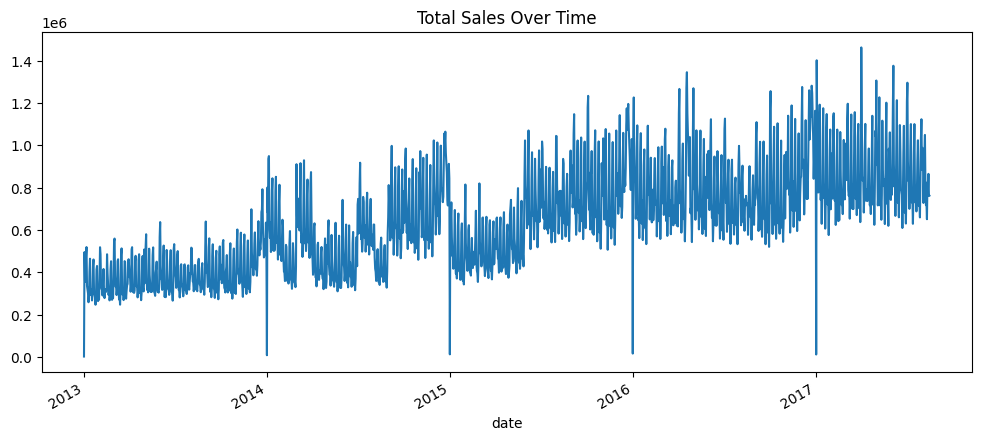

In [12]:
# Total sales over time

total_sales = train.groupby("date")["sales"].sum()
total_sales.plot(figsize = (12, 5), title = "Total Sales Over Time")
plt.show()

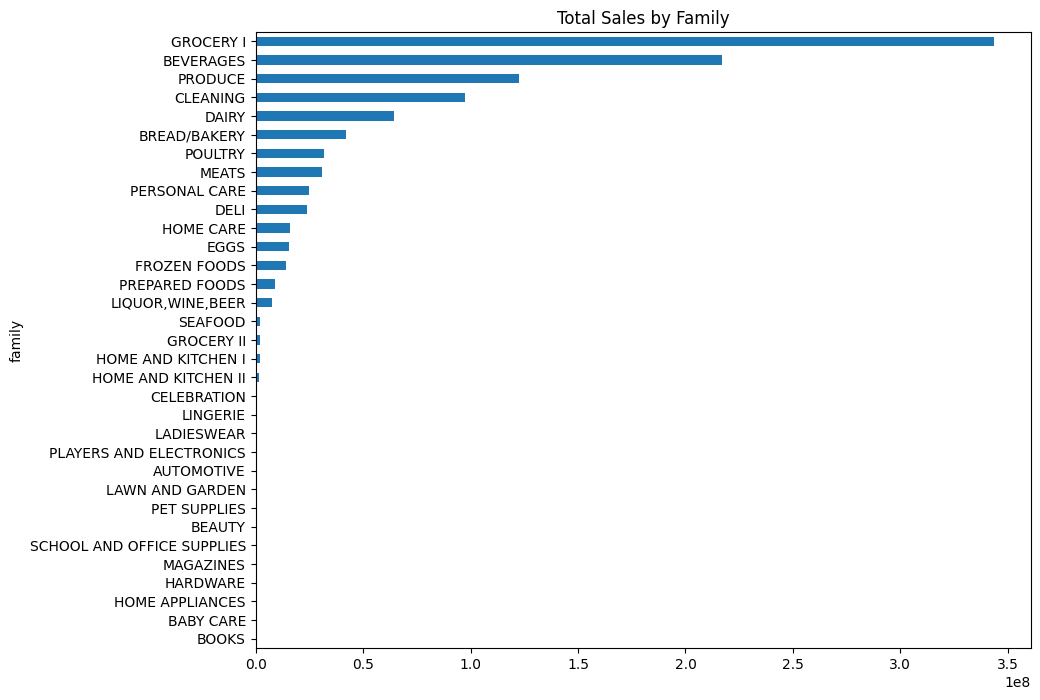

In [13]:
# Total sales by family(Categories)

sales_by_family = train.groupby("family")["sales"].sum().sort_values()
sales_by_family.plot(kind = "barh", figsize = (10, 8), title = "Total Sales by Family")
plt.show()

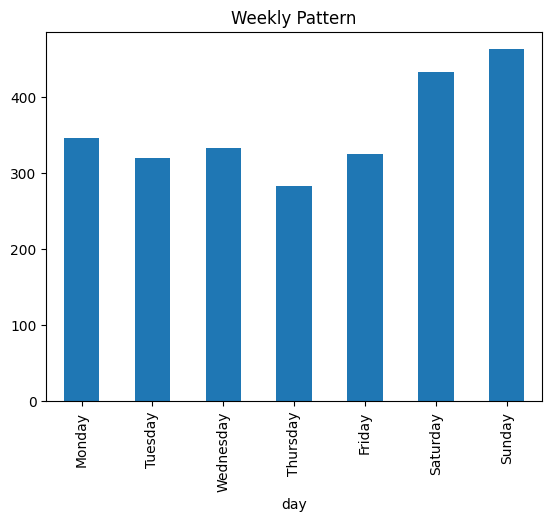

In [14]:
# Weekly pattern

train["day"] = train["date"].dt.day_name()

weekly = train.groupby("day")["sales"].mean()
weekly = weekly.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

weekly.plot(kind = "bar", title = "Weekly Pattern")
plt.show()

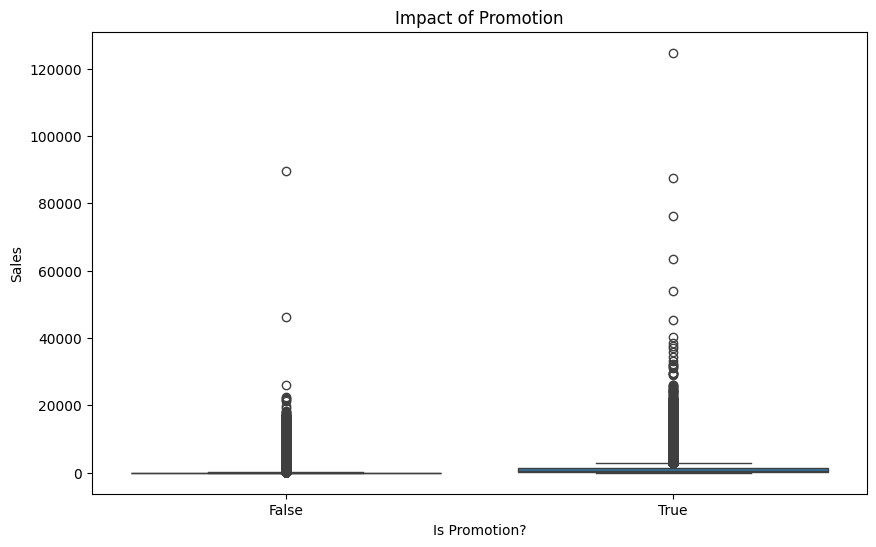

In [15]:
# Impact of Promotion

train["is_promo"] = train["onpromotion"] > 0

fig,ax = plt.subplots(figsize = (10, 6))

sns.boxplot(x = "is_promo", y = "sales", data = train, ax = ax)
ax.set(
    title = "Impact of Promotion",
    xlabel = "Is Promotion?",
    ylabel = "Sales"
)
plt.show()

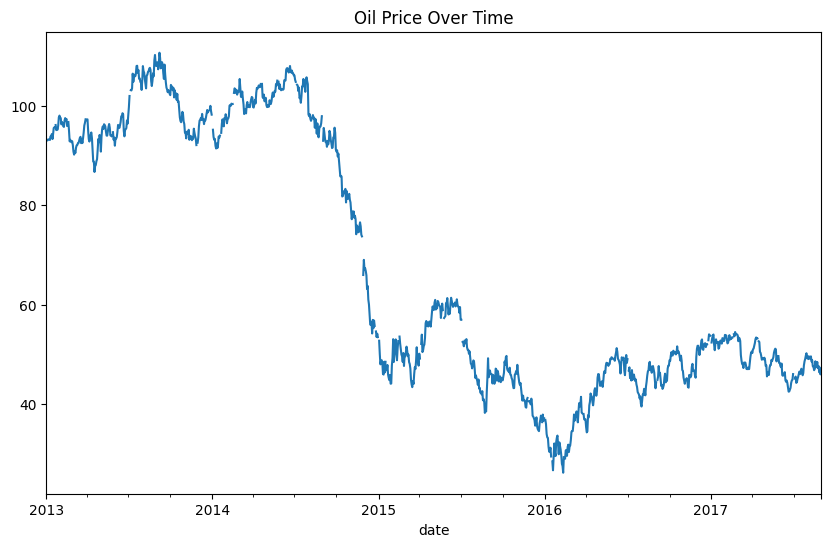

In [16]:
# Oil price over time

oil_price = oil.groupby("date")["dcoilwtico"].mean()
oil_price.plot(figsize = (10, 6), title = "Oil Price Over Time")
plt.show()

In [17]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()
oil_sales = daily_sales.merge(oil, on = "date", how = "left")

oil_sales_norm = oil_sales.copy()

oil_sales_norm["sales"] = (oil_sales["sales"] - oil_sales["sales"].mean()) / oil_sales["sales"].std()
oil_sales_norm["dcoilwtico"] = (oil_sales["dcoilwtico"] - oil_sales["dcoilwtico"].mean()) / oil_sales["dcoilwtico"].std()

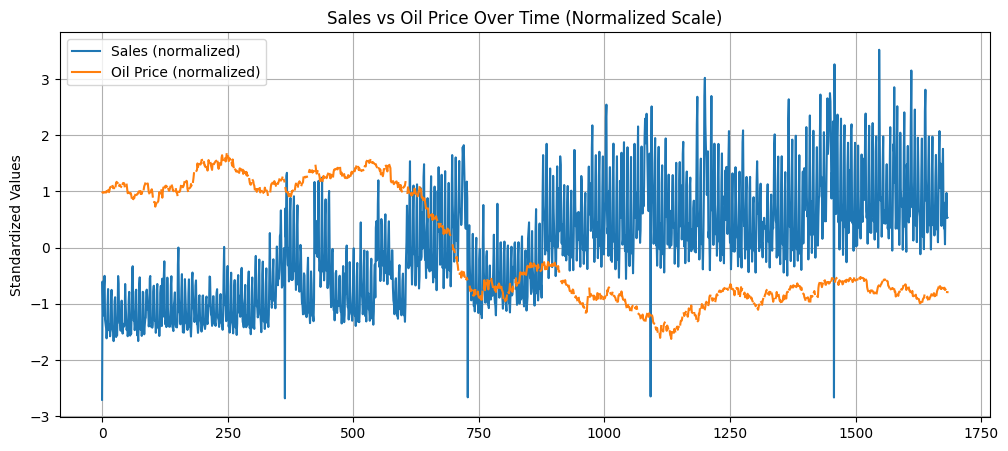

In [18]:
# Sales vs Oil Price Over Time (Normalized Scale)

oil_sales_norm.set_index("date")
oil_sales_norm[["sales", "dcoilwtico"]].plot(figsize = (12,5))

plt.title("Sales vs Oil Price Over Time (Normalized Scale)")
plt.ylabel("Standardized Values")
plt.legend(["Sales (normalized)", "Oil Price (normalized)"])
plt.grid(True)

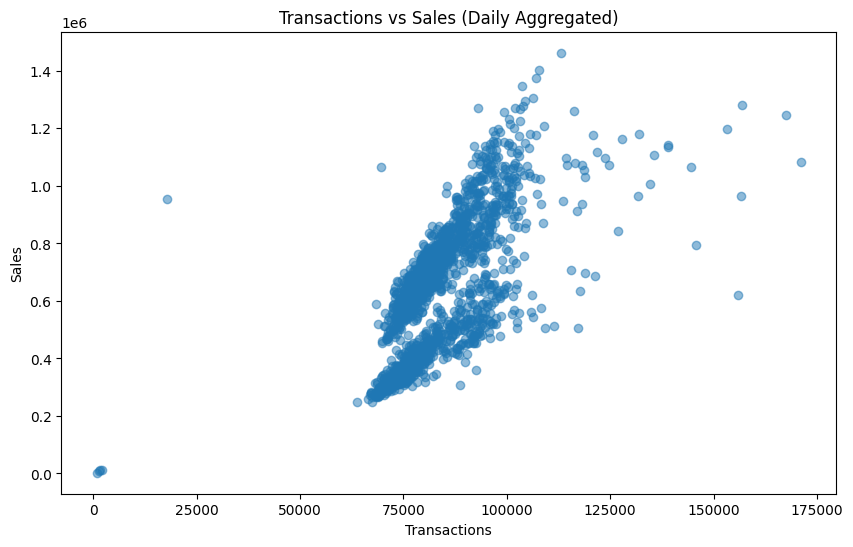

In [19]:
# Transactions vs Sales (Daily Aggregated)

daily = train.groupby("date").agg({"sales": "sum"}).reset_index()

daily_trans = transactions.groupby("date")["transactions"].sum().reset_index()

merged = daily.merge(daily_trans, on = "date")

fig,ax = plt.subplots(figsize = (10, 6))

ax.scatter(merged["transactions"], merged["sales"], alpha = 0.5)
ax.set(
    title = "Transactions vs Sales (Daily Aggregated)",
    xlabel = "Transactions",
    ylabel = "Sales"
)
plt.show()

In [20]:
holidays["type"].value_counts()

,count
type,
Holiday,221
Event,56
Additional,51
Transfer,12
Bridge,5
Work Day,5


In [21]:
holiday_sales = daily_sales.merge(holidays, on = "date", how = "left")
holiday_sales["is_holiday"] = holiday_sales["type"].notnull()
holiday_sales.head()

,date,sales,type,locale,locale_name,description,transferred,is_holiday
0,2013-01-01,2511.62,Holiday,National,Ecuador,Primer dia del ano,False,True
1,2013-01-02,496092.42,NaN,NaN,NaN,NaN,NaN,False
2,2013-01-03,361461.23,NaN,NaN,NaN,NaN,NaN,False
3,2013-01-04,354459.68,NaN,NaN,NaN,NaN,NaN,False
4,2013-01-05,477350.12,Work Day,National,Ecuador,Recupero puente Navidad,False,True


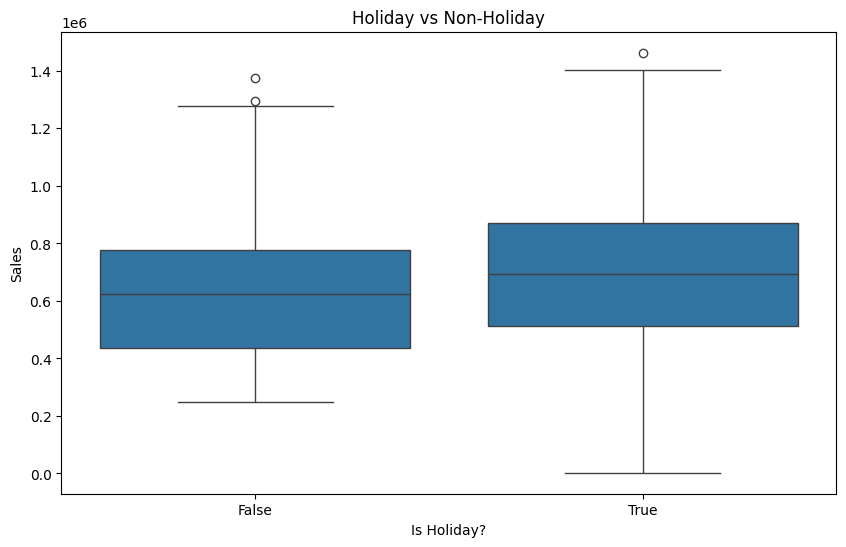

In [22]:
# holiday vs non-holiday

fig,ax = plt.subplots(figsize = (10, 6))

sns.boxplot(x = "is_holiday", y = "sales", data = holiday_sales, ax = ax)
ax.set(
    title = "Holiday vs Non-Holiday",
    xlabel = "Is Holiday?",
    ylabel = "Sales"
)
plt.show()

## **Data Cleaning**

In [23]:
# Create dicts of your dataframes
dfs = {"train": train, "oil": oil, "transactions": transactions, "holidays": holidays}

# Iterate through the dict
for name, df in dfs.items():
  print(f"Check for missing values in {name}:")
  print("\n")
  display(df.isnull().sum())  # Check for missing values
  print("\n" + "-"*100 + "\n")

Check for missing values in train:




,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
day,0
is_promo,0



----------------------------------------------------------------------------------------------------

Check for missing values in oil:




,0
date,0
dcoilwtico,43



----------------------------------------------------------------------------------------------------

Check for missing values in transactions:




,0
date,0
store_nbr,0
transactions,0



----------------------------------------------------------------------------------------------------

Check for missing values in holidays:




,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0



----------------------------------------------------------------------------------------------------



In [24]:
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate()
oil["dcoilwtico"] = oil["dcoilwtico"].bfill()

In [25]:
# Create dicts of your dataframes
dfs = {"train": train, "oil": oil, "transactions": transactions, "holidays": holidays}

# Iterate through the dict
for name, df in dfs.items():
  print(f"Check for missing values in {name}:")
  print("\n")
  display(df.isnull().sum())  # Check for missing values again
  print("\n" + "-"*100 + "\n")

Check for missing values in train:




,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
day,0
is_promo,0



----------------------------------------------------------------------------------------------------

Check for missing values in oil:




,0
date,0
dcoilwtico,0



----------------------------------------------------------------------------------------------------

Check for missing values in transactions:




,0
date,0
store_nbr,0
transactions,0



----------------------------------------------------------------------------------------------------

Check for missing values in holidays:




,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0



----------------------------------------------------------------------------------------------------



In [26]:
# Drop sparse families, that have too many zero sales
family_df = train.groupby(["date","family"])["sales"].sum().reset_index()

family_df.groupby("family")["sales"].apply(
    lambda x: (x == 0).mean()
).sort_values(ascending=False)

,sales
family,
BOOKS,0.83
BABY CARE,0.47
SCHOOL AND OFFICE SUPPLIES,0.40
LADIESWEAR,0.40
CELEBRATION,0.39
PLAYERS AND ELECTRONICS,0.39
PET SUPPLIES,0.39
HOME CARE,0.38
MAGAZINES,0.36


In [27]:
train = train[train["family"] != "BOOKS"]

## **Data Preparation**

In [28]:
df = train.groupby(["date", "family"]).agg({
    "sales": "sum",
    "onpromotion": "sum"
}).reset_index()

In [29]:
df = df.merge(oil, on = "date", how = "left")

In [30]:
trans_daily = transactions.groupby("date")["transactions"].sum().reset_index()
df = df.merge(trans_daily, on = "date", how = "left")

In [31]:
# Fill missing values created after merging external datasets
df["dcoilwtico"] = df["dcoilwtico"].interpolate()
df["transactions"] = df["transactions"].interpolate()

In [32]:
holidays = holidays.rename(columns = {
    "date": "ds",
    "type": "holiday"
})

## **Data Splitting**

In [33]:
# Sort the data first
df = df.sort_values(["family", "date"])

# Train-validation split
train_data = df[df["date"] < "2017-06-01"].copy()
val_data = df[df["date"] >= "2017-06-01"].copy()

print(train_data.shape)
print(val_data.shape)

(51456, 6)
(2432, 6)


## **Forecasting**

In [34]:
# Select one family first
grocery = df[df["family"] == "GROCERY I"].copy()

# Train-Validation set
grocery_train = train_data[train_data["family"] == "GROCERY I"].copy()
grocery_validation = val_data[val_data["family"] == "GROCERY I"].copy()

# Prophet format
grocery_trn = grocery_train.rename(columns = {
    "date": "ds",
    "sales": "y"
})

# Model
model = Prophet(holidays = holidays,
                yearly_seasonality = True,
                weekly_seasonality = True)

# Add regressors
model.add_regressor("onpromotion")
model.add_regressor("transactions")

# Fit model
model.fit(grocery_trn[["ds", "y", "onpromotion", "transactions"]])

# Prepare validation set
grocery_val = grocery_validation.rename(columns = {"date": "ds"})[["ds", "onpromotion", "transactions"]]

# Predict
forecast = model.predict(grocery_val)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [35]:
# Compare actual vs predicted
grocery_validation["predicted_sales"] = forecast["yhat"].values
grocery_validation[["date", "sales", "predicted_sales"]].head()

,date,sales,predicted_sales
51467,2017-06-01,244432.38,240513.38
51499,2017-06-02,269708.91,245812.40
51531,2017-06-03,366851.14,316775.74
51563,2017-06-04,420484.20,349559.61
51595,2017-06-05,287651.91,263293.22


In [36]:
# Evaluate
from sklearn.metrics import mean_squared_error

mape = mean_absolute_percentage_error(grocery_validation["sales"], grocery_validation["predicted_sales"])
rmse = math.sqrt(mean_squared_error(grocery_validation["sales"], grocery_validation["predicted_sales"]))

print(f"MAPE: {mape:.2f}")
print(f"RMSE: {rmse:.2f}")

MAPE: 7.13
RMSE: 22724.08


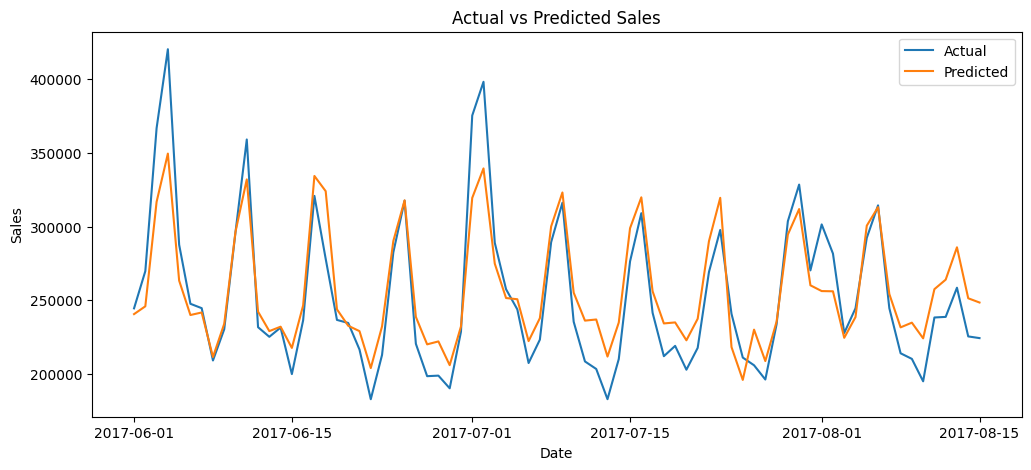

In [37]:
# Plot predictions

fig,ax = plt.subplots(figsize = (12, 5))

ax.plot(grocery_validation["date"], grocery_validation["sales"], label = "Actual")
ax.plot(grocery_validation["date"], grocery_validation["predicted_sales"], label = "Predicted")
ax.set(
    title = "Actual vs Predicted Sales",
    xlabel = "Date",
    ylabel = "Sales"
)
ax.legend()
plt.show()

## **Hyperparameter Tuning**

In [ ]:
start_time = time.time()

# Param grid
param_grid = {
    "changepoint_prior_scale": [0.03, 0.05, 0.07],
    "changepoint_range": [0.8, 0.85],
    "seasonality_prior_scale": [5, 10],
    "holidays_prior_scale": [5, 10],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Generate all parameter combinations
all_params = [
    dict(zip(param_grid.keys(), v))
    for v in itertools.product(*param_grid.values())
]

rmse_list = []
smape_list = []

# Prophet format
grocery_trn = grocery_train.rename(columns = {
    "date": "ds",
    "sales": "y"
})[["ds", "y", "onpromotion", "transactions"]]

# Loop through each parameter combination
for params in all_params:

  print(f"Testing params: {params}")

  # Model
  model = Prophet(
      yearly_seasonality = True,
      weekly_seasonality = True,
      holidays = holidays,
      **params
  )

  # Add regressors
  model.add_regressor("onpromotion")
  model.add_regressor("transactions")

  # Fit model
  model.fit(grocery_trn)

  # Cross Validation
  df_cv = cross_validation(model, initial = "730 days", period = "30 days", horizon = "30 days")

  # Performance metrics
  df_perf = performance_metrics(df_cv, rolling_window = 1)

  rmse_list.append(df_perf["rmse"].values[0])
  smape_list.append(df_perf["smape"].values[0])

  print(df_perf[["rmse", "smape"]])

# Store results
tuning_results = pd.DataFrame(all_params)
tuning_results["rmse"] = rmse_list
tuning_results["smape"] = smape_list

# Best Params
best_params = (tuning_results.sort_values("rmse").reset_index(drop = True).iloc[0])

print("\nBest Params:")
print(best_params)

print(f"\nTotal time: {time.time() - start_time:.2f} seconds")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Testing params: {'changepoint_prior_scale': 0.03, 'changepoint_range': 0.8, 'seasonality_prior_scale': 5, 'holidays_prior_scale': 5, 'seasonality_mode': 'additive'}


INFO:prophet:Making 29 forecasts with cutoffs between 2015-01-12 00:00:00 and 2017-05-01 00:00:00


  0%|          | 0/29 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


...

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


      rmse  smape
0 34598.27   0.09
Testing params: {'changepoint_prior_scale': 0.07, 'changepoint_range': 0.85, 'seasonality_prior_scale': 10, 'holidays_prior_scale': 10, 'seasonality_mode': 'multiplicative'}


INFO:prophet:Making 29 forecasts with cutoffs between 2015-01-12 00:00:00 and 2017-05-01 00:00:00


  0%|          | 0/29 [00:00<?, ?it/s]

      rmse  smape
0 35048.89   0.09

Best Params:
changepoint_prior_scale        0.03
changepoint_range              0.85
seasonality_prior_scale           5
holidays_prior_scale              5
seasonality_mode           additive
rmse                       34234.50
smape                          0.09
Name: 0, dtype: object

Total time: 806.88 seconds


In [ ]:
best_params

,0
changepoint_prior_scale,0.03
changepoint_range,0.85
seasonality_prior_scale,5
holidays_prior_scale,5
seasonality_mode,additive
rmse,34234.50
smape,0.09


## **Final Forecasting**

In [38]:
## Prediction on historical data

# Get all unique product families
families = df["family"].unique()

# Store forecasts
validation_forecasts = []
future_forecasts = []

for fam in families:

  print(f"Training model for: {fam}")

  # Prepare training data
  family_trn = train_data[train_data["family"] == fam].copy()

  family_trn = family_trn.rename(columns = {
      "date": "ds",
      "sales": "y"
  })

  # Prophet model
  model = Prophet(
      holidays = holidays,
      yearly_seasonality = True,
      weekly_seasonality = True)

  # Add regressors
  model.add_regressor("onpromotion")
  model.add_regressor("transactions")

  # Fit the model
  model.fit(family_trn[["ds", "y", "onpromotion", "transactions"]])

  # Prepare validation data
  family_validation = val_data[val_data["family"] == fam].copy()

  family_val = family_validation.rename(columns = {"date": "ds"})[["ds", "onpromotion", "transactions"]]

  # Forecast
  forecast = model.predict(family_val)

  family_validation["predicted_sales"] = forecast["yhat"].values
  validation_forecasts.append(family_validation)

  ## Prediction on future data

  # Use full data
  full_family = df[df["family"] == fam].copy()

  full_family = full_family.rename(columns = {
      "date": "ds",
      "sales": "y"
  })

  # Prophet model
  future_model = Prophet(
      holidays = holidays,
      yearly_seasonality = True,
      weekly_seasonality = True)

  # Add regressors
  future_model.add_regressor("onpromotion")
  future_model.add_regressor("transactions")

  # Fit the model with full dataset
  future_model.fit(full_family[["ds", "y", "onpromotion", "transactions"]])

  # Create future dates (next 30 days)
  future = future_model.make_future_dataframe(periods = 30)

  # Merge historical regressors
  future = future.merge(full_family[["ds", "onpromotion", "transactions"]], on = "ds", how = "left")

  # Fill future regressor NaNs with mean
  future["onpromotion"] = future["onpromotion"].fillna(full_family["onpromotion"].mean())
  future["transactions"] = future["transactions"].fillna(full_family["transactions"].mean())

  # Predict future sales
  future_pred = future_model.predict(future)

  future_pred["family"] = fam

  future_forecasts.append(future_pred[["ds", "family", "yhat"]])

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Training model for: AUTOMOTIVE


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Training model for: BABY CARE


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


...

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Training model for: SCHOOL AND OFFICE SUPPLIES


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Training model for: SEAFOOD


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [39]:
# Final validation dataframe
validation_results = pd.concat(
    validation_forecasts,
    ignore_index = True)

# Final future forecast dataframe
future_results = pd.concat(
    future_forecasts,
    ignore_index = True)

In [40]:
# Evaluate
from sklearn.metrics import mean_squared_error

wmape = weighted_mape(validation_results["sales"], validation_results["predicted_sales"])
mape = mean_absolute_percentage_error(validation_results["sales"], validation_results["predicted_sales"])
rmse = math.sqrt(mean_squared_error(validation_results["sales"], validation_results["predicted_sales"]))

print(f"WMAPE: {wmape:.2f}%")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

WMAPE: 9.99%
MAPE: 21.64%
RMSE: 7494.21


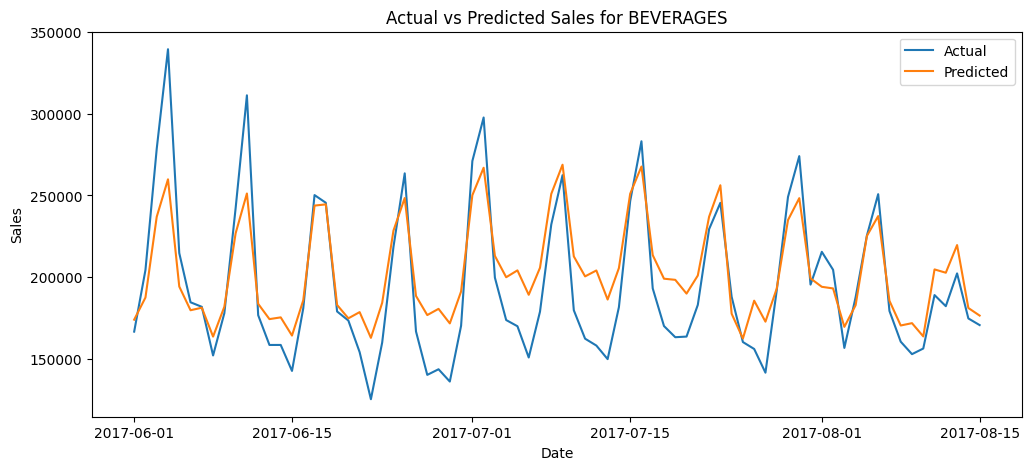

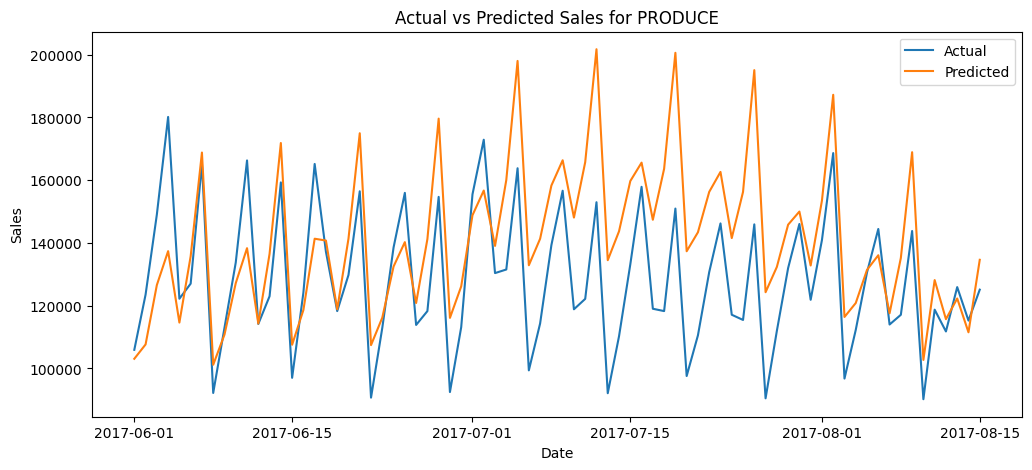

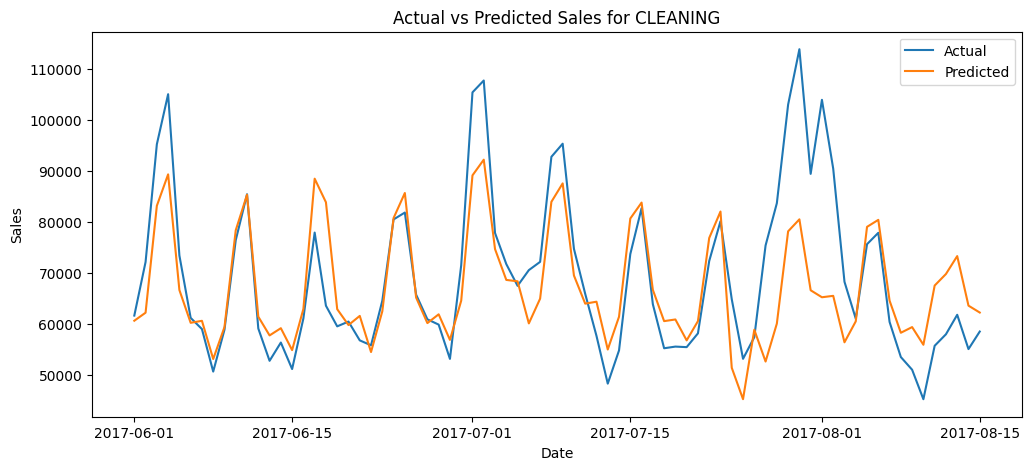

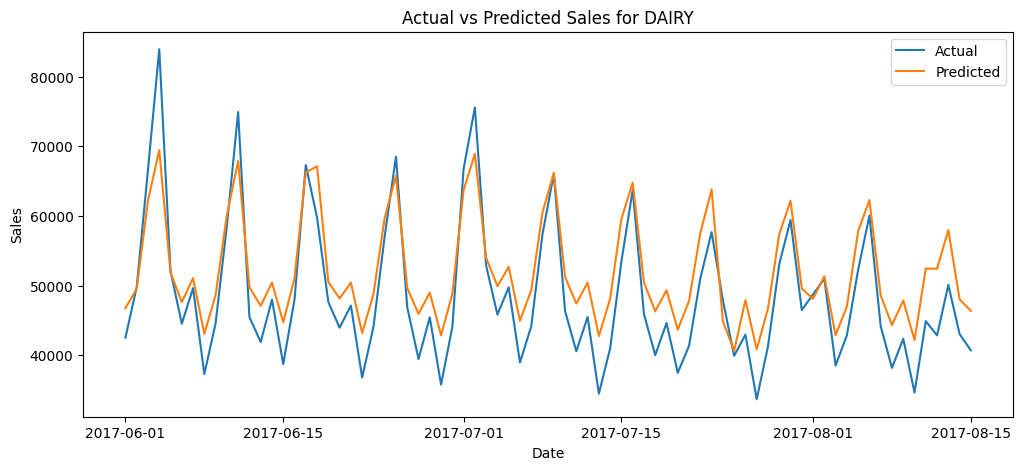

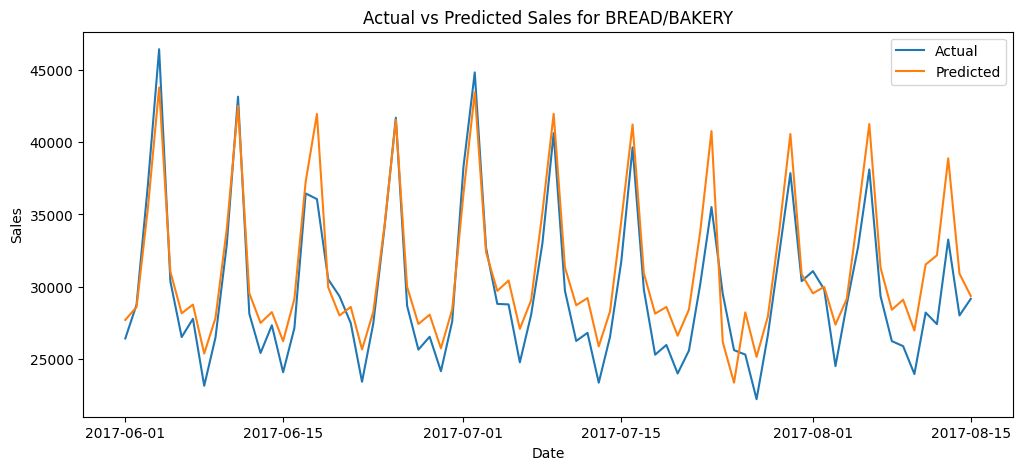

In [41]:
# Plot predictions

top_families = (
    df.groupby("family")["sales"].sum().sort_values(ascending = False)[1:6].index
)

for fam in top_families:
  family_plot = validation_results[validation_results["family"] == fam]

  fig,ax = plt.subplots(figsize = (12, 5))

  ax.plot(family_plot["date"], family_plot["sales"], label = "Actual")
  ax.plot(family_plot["date"], family_plot["predicted_sales"], label = "Predicted")

  ax.set(
      title = f"Actual vs Predicted Sales for {fam}",
      xlabel = "Date",
      ylabel = "Sales"
  )

  ax.legend()
  plt.show()

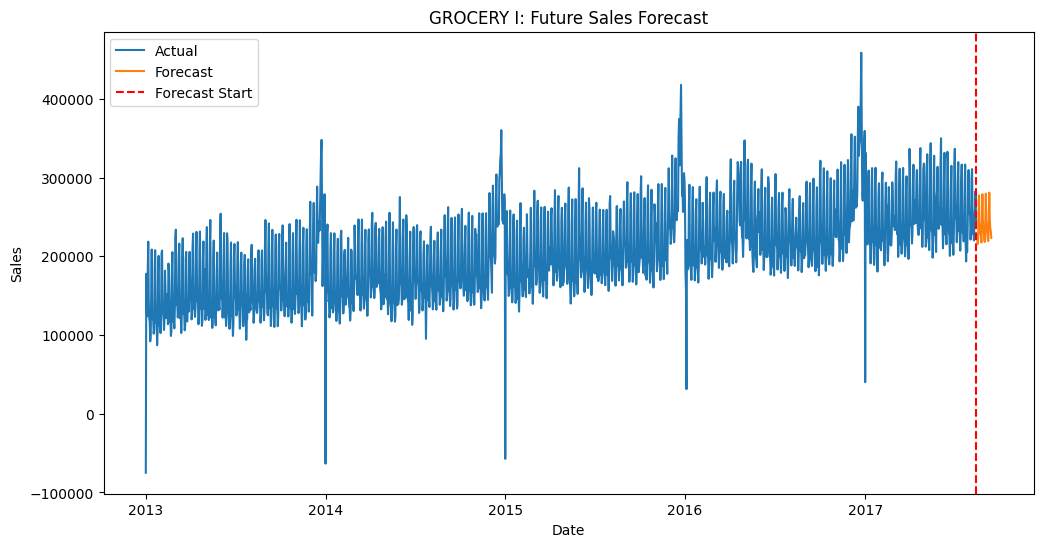

In [43]:
# Plot future predictions (Grocery I)

future_grocery = future_results[future_results["family"] == "GROCERY I"]

future_part = future_grocery[future_grocery["ds"] > "2017-08-15"]
history_part = future_grocery[future_grocery["ds"] <= "2017-08-15"]

fig,ax = plt.subplots(figsize = (12, 6))

ax.plot(history_part["ds"], history_part["yhat"], label = "Actual")
ax.plot(future_part["ds"], future_part["yhat"], label = "Forecast")

ax.axvline(pd.to_datetime("2017-08-15"), linestyle = "--", color = "red", label = "Forecast Start")

ax.set(
    title = "GROCERY I: Future Sales Forecast",
    xlabel = "Date",
    ylabel = "Sales"
)
ax.legend()
plt.show()

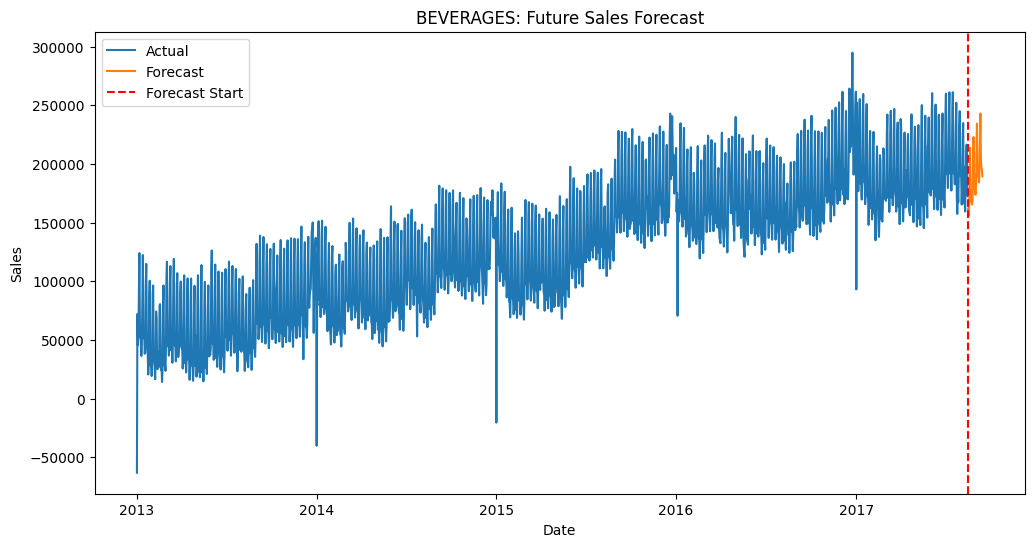

In [44]:
# Plot future predictions (Beverages)

future_grocery = future_results[future_results["family"] == "BEVERAGES"]

future_part = future_grocery[future_grocery["ds"] > "2017-08-15"]
history_part = future_grocery[future_grocery["ds"] <= "2017-08-15"]

fig,ax = plt.subplots(figsize = (12, 6))

ax.plot(history_part["ds"], history_part["yhat"], label = "Actual")
ax.plot(future_part["ds"], future_part["yhat"], label = "Forecast")

ax.axvline(pd.to_datetime("2017-08-15"), linestyle = "--", color = "red", label = "Forecast Start")

ax.set(
    title = "BEVERAGES: Future Sales Forecast",
    xlabel = "Date",
    ylabel = "Sales"
)
ax.legend()
plt.show()

In [12]:
from google.colab import files
import json

# Upload the notebook you downloaded from Colab
uploaded = files.upload()

input_file = next(iter(uploaded))
output_file = input_file.replace(".ipynb", "-Github.ipynb")

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
nb.get("metadata", {}).pop("widgets", None)

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f)

print(f"Created: {output_file}")

# Download cleaned notebook
files.download(output_file)

Saving Store_Sales_Time_Series_Forecasting(With_Regressors).ipynb to Store_Sales_Time_Series_Forecasting(With_Regressors).ipynb
Created: Store_Sales_Time_Series_Forecasting(With_Regressors)-Github.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>